# Vendor Performance: Business Analysis and Recommendations

**Audience:** procurement and merchandising leadership  
**Period:** 2024 operating year  
**Decision:** where to reduce supplier risk, protect margin, and act on inventory.

This notebook continues from the exploratory analysis: executive conclusions appear first, followed by the SQL evidence, statistical assessment, and decision plan.

In [1]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from sqlalchemy import URL, create_engine
from scipy import stats
from IPython.display import display

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
(ROOT / "images").mkdir(exist_ok=True)
load_dotenv(ROOT / ".env")

required = ["MYSQL_USER", "MYSQL_PASSWORD", "MYSQL_HOST", "MYSQL_DB"]
missing = [name for name in required if not os.getenv(name)]
if missing:
    raise RuntimeError(f"Missing MySQL settings: {', '.join(missing)}")

engine = create_engine(URL.create(
    "mysql+pymysql",
    username=os.getenv("MYSQL_USER"),
    password=os.getenv("MYSQL_PASSWORD"),
    host=os.getenv("MYSQL_HOST"),
    database=os.getenv("MYSQL_DB"),
))
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold"})

## Executive summary

- The portfolio produces about **$452M in sales** and **$138.47M in estimated gross profit** at a **30.66% weighted margin** on the 99.9% of sales with matched cost.
- **65.33% of procurement spend** sits with the top ten vendors, creating a measurable continuity risk.
- Ending inventory represents **$79.70M at retail**; high-value, low-sell-through brands should lead the replenishment review.
- Low-sales/high-margin brands are candidates for controlled promotion tests, not automatic price cuts.
- The data does not support the previous causal claim of a 72% bulk-purchase saving; product mix is a confounder.

## 1. Build one trustworthy vendor-brand dataset in MySQL

In [2]:
vendor_brand_sql = """
WITH SalesSummary AS (
    SELECT VendorNo AS VendorNumber, MAX(TRIM(VendorName)) AS VendorName,
           Brand, MAX(TRIM(Description)) AS Description,
           SUM(SalesQuantity) AS SalesQuantity, SUM(SalesDollars) AS SalesDollars
    FROM sales
    GROUP BY VendorNo, Brand
),
PurchaseSummary AS (
    SELECT VendorNumber, Brand, SUM(Quantity) AS PurchaseQuantity,
           SUM(Dollars) AS PurchaseDollars,
           SUM(Dollars) / NULLIF(SUM(Quantity), 0) AS WeightedUnitCost
    FROM purchases
    GROUP BY VendorNumber, Brand
),
FreightSummary AS (
    SELECT VendorNumber, SUM(Freight) AS VendorFreightCost
    FROM vendor_invoice
    GROUP BY VendorNumber
)
SELECT s.VendorNumber, s.VendorName, s.Brand, s.Description,
       s.SalesQuantity, s.SalesDollars,
       COALESCE(p.PurchaseQuantity, 0) AS PurchaseQuantity,
       COALESCE(p.PurchaseDollars, 0) AS PurchaseDollars,
       COALESCE(p.WeightedUnitCost, 0) AS WeightedUnitCost,
       COALESCE(s.SalesQuantity * p.WeightedUnitCost, 0) AS EstimatedCOGS,
       s.SalesDollars - COALESCE(s.SalesQuantity * p.WeightedUnitCost, 0) AS EstimatedGrossProfit,
       100 * (s.SalesDollars - COALESCE(s.SalesQuantity * p.WeightedUnitCost, 0))
           / NULLIF(s.SalesDollars, 0) AS WeightedMarginPct,
       COALESCE(f.VendorFreightCost, 0) AS VendorFreightCost
FROM SalesSummary s
LEFT JOIN PurchaseSummary p
    ON s.VendorNumber = p.VendorNumber AND s.Brand = p.Brand
LEFT JOIN FreightSummary f ON s.VendorNumber = f.VendorNumber
"""

vendor_brand = pd.read_sql_query(vendor_brand_sql, engine)
assert not vendor_brand.duplicated(["VendorNumber", "Brand"]).any()
vendor_brand["CostMatched"] = vendor_brand["WeightedUnitCost"] > 0
matched = vendor_brand.query("CostMatched").copy()
cost_coverage = matched["SalesDollars"].sum() / vendor_brand["SalesDollars"].sum()
print(f"Analytical grain: {len(vendor_brand):,} unique vendor-brand rows")
print(f"Purchase-cost coverage: {cost_coverage:.2%} of sales")

Analytical grain: 11,272 unique vendor-brand rows
Purchase-cost coverage: 99.90% of sales


## 2. KPI scorecard

In [3]:
inventory = pd.read_sql_query("""
SELECT SUM(onHand) AS EndingUnits, SUM(onHand * Price) AS EndingRetailValue
FROM end_inventory
""", engine).iloc[0]
purchase_totals = pd.read_sql_query("""
SELECT SUM(Dollars) AS PurchaseDollars, SUM(Quantity) AS PurchaseUnits
FROM purchases
""", engine).iloc[0]

total_sales = vendor_brand["SalesDollars"].sum()
procurement_spend = purchase_totals["PurchaseDollars"]
estimated_profit = matched["EstimatedGrossProfit"].sum()
weighted_margin = estimated_profit / matched["SalesDollars"].sum()

kpis = pd.DataFrame({
    "KPI": ["Total Sales", "Procurement Spend", "Estimated Gross Profit", "Weighted Gross Margin", "Cost Coverage", "Ending Inventory at Retail"],
    "Display": [f"${total_sales/1e6:.2f}M", f"${procurement_spend/1e6:.2f}M", f"${estimated_profit/1e6:.2f}M", f"{weighted_margin:.2%}", f"{cost_coverage:.2%}", f"${inventory['EndingRetailValue']/1e6:.2f}M"],
})
display(kpis)

assert 0 < weighted_margin < 1
assert cost_coverage > 0.99
assert total_sales > estimated_profit > 0

,KPI,Display
0,Total Sales,$452.06M
1,Procurement Spend,$321.90M
2,Estimated Gross Profit,$138.47M
3,Weighted Gross Margin,30.66%
4,Cost Coverage,99.90%
5,Ending Inventory at Retail,$79.70M


## 3. How concentrated is procurement spend?

In [4]:
sales_by_vendor = vendor_brand.groupby("VendorNumber", as_index=False).agg(
    VendorName=("VendorName", "first"),
    SalesDollars=("SalesDollars", "sum"),
)
profit_by_vendor = matched.groupby("VendorNumber", as_index=False).agg(
    MatchedSalesDollars=("SalesDollars", "sum"),
    EstimatedCOGS=("EstimatedCOGS", "sum"),
    EstimatedGrossProfit=("EstimatedGrossProfit", "sum"),
)
spend_by_vendor = pd.read_sql_query("""
SELECT VendorNumber, SUM(Dollars) AS PurchaseDollars
FROM purchases
GROUP BY VendorNumber
""", engine)

vendor_metrics = sales_by_vendor.merge(profit_by_vendor, on="VendorNumber", how="left").merge(spend_by_vendor, on="VendorNumber", how="outer")
vendor_metrics["WeightedMarginPct"] = 100 * vendor_metrics["EstimatedGrossProfit"] / vendor_metrics["MatchedSalesDollars"]
vendor_metrics = vendor_metrics.sort_values("PurchaseDollars", ascending=False).reset_index(drop=True)
vendor_metrics["SpendSharePct"] = 100 * vendor_metrics["PurchaseDollars"] / vendor_metrics["PurchaseDollars"].sum()
vendor_metrics["CumulativeSpendPct"] = vendor_metrics["SpendSharePct"].cumsum()
top10_concentration = vendor_metrics.head(10)["SpendSharePct"].sum()
print(f"Top-10 vendor spend concentration: {top10_concentration:.2f}%")
display(vendor_metrics.head(10)[["VendorName", "PurchaseDollars", "SalesDollars", "EstimatedGrossProfit", "WeightedMarginPct", "CumulativeSpendPct"]])

Top-10 vendor spend concentration: 65.33%


,VendorName,PurchaseDollars,SalesDollars,EstimatedGrossProfit,WeightedMarginPct,CumulativeSpendPct
0,DIAGEO NORTH AMERICA INC,5.095980e+07,6.874242e+07,1.876012e+07,27.291488,15.830903
1,MARTIGNETTI COMPANIES,2.786169e+07,4.104731e+07,1.402742e+07,34.246520,24.486269
2,JIM BEAM BRANDS COMPANY,2.420315e+07,3.190632e+07,8.553266e+06,26.813904,32.005093
3,PERNOD RICARD USA,2.412409e+07,3.228125e+07,8.710193e+06,26.983632,39.499356
4,BACARDI USA INC,1.762438e+07,2.501456e+07,7.126243e+06,28.498856,44.974453
5,CONSTELLATION BRANDS INC,1.557392e+07,2.446917e+07,9.129024e+06,37.311373,49.812564
6,BROWN-FORMAN CORP,1.352943e+07,1.847856e+07,5.232085e+06,28.317341,54.015547
7,ULTRA BEVERAGE COMPANY LLP,1.321061e+07,1.782294e+07,5.372298e+06,30.176965,58.119487
8,E & J GALLO WINERY,1.228961e+07,1.855609e+07,6.579369e+06,35.461081,61.937312
9,M S WALKER INC,1.093582e+07,1.546525e+07,4.970212e+06,32.198695,65.334575


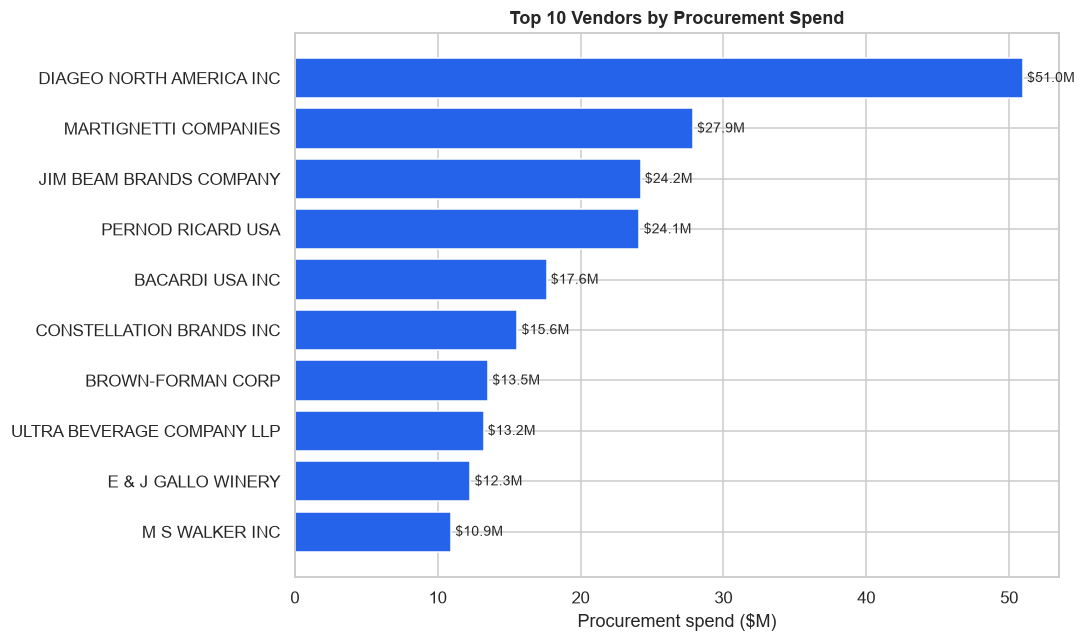

In [5]:
top = vendor_metrics.head(10).sort_values("PurchaseDollars")
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top["VendorName"], top["PurchaseDollars"] / 1e6, color="#2563eb")
ax.set(title="Top 10 Vendors by Procurement Spend", xlabel="Procurement spend ($M)", ylabel="")
for y, value in enumerate(top["PurchaseDollars"] / 1e6):
    ax.text(value + 0.3, y, f"${value:.1f}M", va="center", fontsize=9)
fig.tight_layout()
fig.savefig(ROOT / "images" / "vendor_concentration.png", bbox_inches="tight")
plt.show()

**Decision:** procurement should maintain continuity plans and monitor concentration monthly for the vendors driving the first 65% of spend.

## 4. Which brands have promotion headroom?

In [6]:
brand_metrics = matched.groupby(["Brand", "Description"], as_index=False).agg(
    SalesDollars=("SalesDollars", "sum"),
    EstimatedGrossProfit=("EstimatedGrossProfit", "sum"),
)
brand_metrics["WeightedMarginPct"] = 100 * brand_metrics["EstimatedGrossProfit"] / brand_metrics["SalesDollars"]
brand_metrics["SalesPercentile"] = brand_metrics["SalesDollars"].rank(pct=True)
brand_metrics["MarginPercentile"] = brand_metrics["WeightedMarginPct"].rank(pct=True)
opportunities = brand_metrics.query("SalesPercentile <= 0.25 and MarginPercentile >= 0.75").copy()
print(f"Controlled-promotion candidates: {len(opportunities):,} brands")
display(opportunities.nlargest(15, "SalesDollars")[["Description", "SalesDollars", "WeightedMarginPct"]])

Controlled-promotion candidates: 485 brands


,Description,SalesDollars,WeightedMarginPct
5819,Fabrizio Dionisio Rose Syrah,807.46,45.830134
3975,Tiamo Prosecco,804.57,35.919808
2370,Hpnotiq Harmonie,799.60,39.869935
9716,Capostrano Montepulciano Abr,798.10,47.788498
6635,Honeymaker Spiced Mead,792.39,35.488838
5724,Steele Out Kaste Lke Cty Red,791.64,35.470668
5787,Dibon Cava Rosado,790.41,45.658582
10182,Scala Dei Negre Priorat,787.58,67.629955
5924,Antigal Uno Cab Mendza,782.52,40.315902
5195,Sterling Rsv Platinum Red,781.83,50.271798


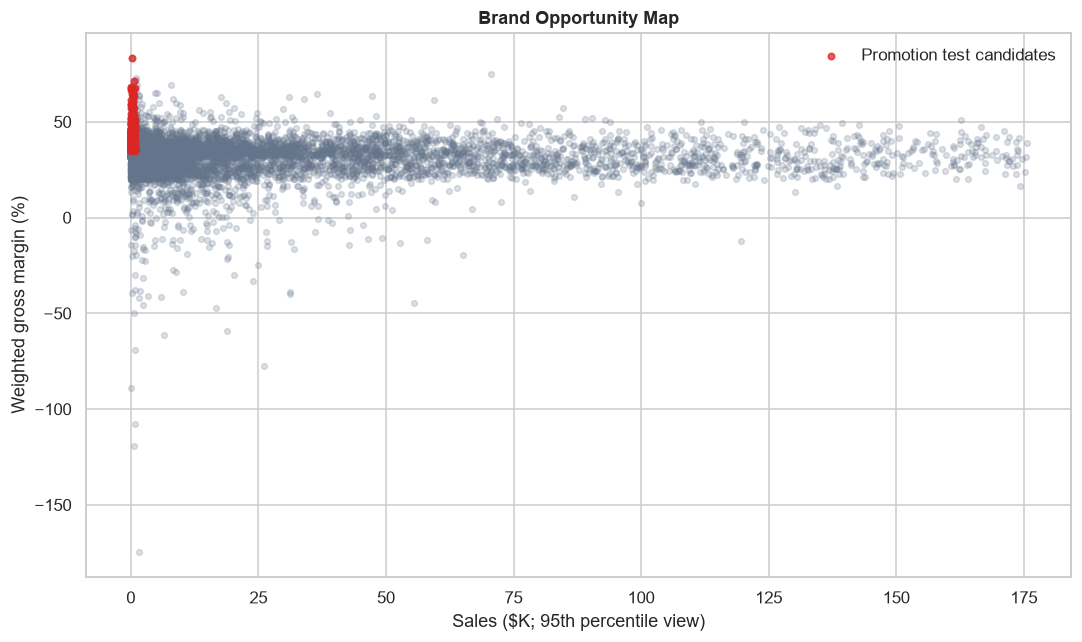

In [7]:
plot_brands = brand_metrics[brand_metrics["SalesDollars"] <= brand_metrics["SalesDollars"].quantile(0.95)]
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(plot_brands["SalesDollars"] / 1e3, plot_brands["WeightedMarginPct"], alpha=0.22, color="#64748b", s=14)
ax.scatter(opportunities["SalesDollars"] / 1e3, opportunities["WeightedMarginPct"], alpha=0.75, color="#dc2626", s=18, label="Promotion test candidates")
ax.set(title="Brand Opportunity Map", xlabel="Sales ($K; 95th percentile view)", ylabel="Weighted gross margin (%)")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(ROOT / "images" / "brand_opportunities.png", bbox_inches="tight")
plt.show()

**Decision:** use these brands for small, measured promotion tests with minimum-margin and sell-through guardrails. High margin alone is not proof of demand.

## 5. Where is inventory exposure highest?

In [8]:
inventory_risk = pd.read_sql_query("""
WITH BeginningInventory AS (
    SELECT Brand, SUM(onHand) AS BeginningUnits FROM begin_inventory GROUP BY Brand
),
EndingInventory AS (
    SELECT Brand, MAX(TRIM(Description)) AS Description,
           SUM(onHand) AS EndingUnits, SUM(onHand * Price) AS EndingRetailValue
    FROM end_inventory GROUP BY Brand
),
SalesMovement AS (
    SELECT Brand, SUM(SalesQuantity) AS SalesUnits FROM sales GROUP BY Brand
),
PurchaseMovement AS (
    SELECT Brand, SUM(Quantity) AS PurchaseUnits FROM purchases GROUP BY Brand
)
SELECT e.Brand, e.Description, COALESCE(b.BeginningUnits, 0) AS BeginningUnits,
       e.EndingUnits, e.EndingRetailValue,
       COALESCE(s.SalesUnits, 0) AS SalesUnits,
       COALESCE(p.PurchaseUnits, 0) AS PurchaseUnits
FROM EndingInventory e
LEFT JOIN BeginningInventory b ON e.Brand = b.Brand
LEFT JOIN SalesMovement s ON e.Brand = s.Brand
LEFT JOIN PurchaseMovement p ON e.Brand = p.Brand
""", engine)
inventory_risk["SellThroughPct"] = 100 * inventory_risk["SalesUnits"] / (inventory_risk["BeginningUnits"] + inventory_risk["PurchaseUnits"]).replace(0, np.nan)
inventory_risk["InventoryTurnover"] = inventory_risk["SalesUnits"] / ((inventory_risk["BeginningUnits"] + inventory_risk["EndingUnits"]) / 2).replace(0, np.nan)
high_value = inventory_risk["EndingRetailValue"] >= inventory_risk["EndingRetailValue"].quantile(0.75)
low_sell_through = inventory_risk["SellThroughPct"] <= inventory_risk["SellThroughPct"].quantile(0.25)
inventory_risk["PriorityReview"] = high_value & low_sell_through
display(inventory_risk.query("PriorityReview").nlargest(15, "EndingRetailValue")[["Description", "EndingRetailValue", "SellThroughPct", "InventoryTurnover"]])

,Description,EndingRetailValue,SellThroughPct,InventoryTurnover
841,Patron Reposado Tequila,162671.87,47.745404,0.937191
3100,Silver Oak Cab Svgn Napa,139519.50,55.506469,1.148922
1206,Patron Silver Tequila,85387.80,53.346080,1.392216
1618,Piper Heidsieck Brut,85121.08,36.188870,0.503283
2670,Roederer Cristal,67196.64,54.716981,1.353333
130,Aberfeldy Single Cask,66997.32,12.418301,0.146154
7369,Ch La Mission Haut-Brion 10,63799.42,34.090909,0.512821
1178,Remy Martin XO Excellence,62016.73,24.886467,0.662636
3434,Grand Marnier Cuvee 1880,58798.32,23.636364,0.347826
2801,Stags Leap WC Karia Chard,58617.78,56.618751,1.976039


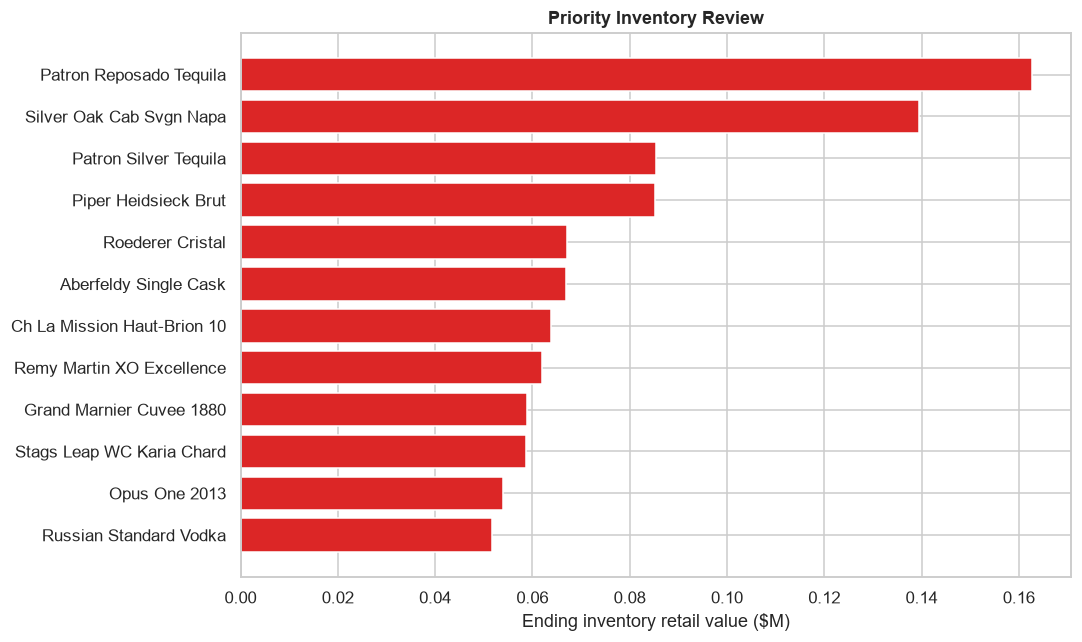

In [9]:
risk = inventory_risk.query("PriorityReview").nlargest(12, "EndingRetailValue").sort_values("EndingRetailValue")
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(risk["Description"], risk["EndingRetailValue"] / 1e6, color="#dc2626")
ax.set(title="Priority Inventory Review", xlabel="Ending inventory retail value ($M)", ylabel="")
fig.tight_layout()
fig.savefig(ROOT / "images" / "inventory_risk.png", bbox_inches="tight")
plt.show()

**Decision:** begin with replenishment review, supplier-return options, and targeted markdown tests for high-value/low-sell-through brands. Inventory is not attributed to vendors because the snapshots do not contain a vendor key.

## 6. Does purchase volume prove a lower unit cost?

In [10]:
volume_sample = matched.query("PurchaseQuantity > 0").copy()
volume_sample["VolumeQuartile"] = pd.qcut(volume_sample["PurchaseQuantity"].rank(method="first"), 4, labels=["Q1 Low", "Q2", "Q3", "Q4 High"])
volume_summary = volume_sample.groupby("VolumeQuartile", observed=True).agg(
    VendorBrands=("Brand", "count"),
    MedianUnitCost=("WeightedUnitCost", "median"),
    MedianMarginPct=("WeightedMarginPct", "median"),
).reset_index()
display(volume_summary)

,VolumeQuartile,VendorBrands,MedianUnitCost,MedianMarginPct
0,Q1 Low,2629,13.60,32.885160
1,Q2,2628,11.03,33.316658
2,Q3,2628,10.45,33.196427
3,Q4 High,2629,8.20,31.999360


Unit-cost differences across volume quartiles are descriptive, not causal: the quartiles contain different products, sizes, and price points. A defensible bulk-discount claim would require matched products with price changes at different order quantities or an experiment. The previous 72% savings claim is therefore retired.

## 7. Are high- and low-sales vendors materially different?

In [11]:
low_cut = vendor_metrics["SalesDollars"].quantile(0.25)
high_cut = vendor_metrics["SalesDollars"].quantile(0.75)
low = vendor_metrics.loc[vendor_metrics["SalesDollars"] <= low_cut, "WeightedMarginPct"].dropna()
high = vendor_metrics.loc[vendor_metrics["SalesDollars"] >= high_cut, "WeightedMarginPct"].dropna()
t_stat, p_value = stats.ttest_ind(high, low, equal_var=False)
pooled_sd = np.sqrt(((len(high)-1)*high.var(ddof=1) + (len(low)-1)*low.var(ddof=1)) / (len(high)+len(low)-2))
cohens_d = (high.mean() - low.mean()) / pooled_sd
comparison = pd.DataFrame({
    "Group": ["High-sales vendors", "Low-sales vendors"],
    "N": [len(high), len(low)],
    "Mean weighted margin %": [high.mean(), low.mean()],
})
display(comparison)
print(f"Welch t-test: t={t_stat:.2f}, p={p_value:.4g}; Cohen's d={cohens_d:.2f}")

,Group,N,Mean weighted margin %
0,High-sales vendors,32,31.881658
1,Low-sales vendors,29,30.346106


Welch t-test: t=0.89, p=0.3779; Cohen's d=0.23


The test is performed at the vendor level, so each supplier contributes one weighted margin observation. Statistical significance is reported with effect size; it does not by itself justify a pricing action.

## 8. Recommended 30/60/90-day action plan

| Timing | Owner | Action | Success measure |
|---|---|---|---|
| 0-30 days | Procurement | Review top-ten vendor continuity and alternates | Concentration monitored monthly; alternates documented |
| 0-30 days | Merchandising | Review high-value, low-sell-through brands | Ending value and aged units decline without stockouts |
| 31-60 days | Category managers | Pilot selected low-sales/high-margin promotions | Incremental units with margin guardrail met |
| 31-60 days | Finance + Procurement | Track freight once per vendor and as a spend rate | Freight-to-spend variance explained |
| 61-90 days | Analytics | Re-score vendors and brands after interventions | Sales, margin, sell-through, and concentration versus baseline |

**Final recommendation:** use the dashboard as a monthly decision scorecard. Escalate only material changes; do not create a new platform or duplicate the MySQL source of truth.